# Pedestrian Flows – Seasonal Design Days (Winter vs Summer)

This notebook will:

- Load pedestrian **edge geometries** and **hourly flows**.
- Inspect schema and date/time structure.
- Later:
  - Define “design days” for **winter** and **summer** based on date ranges.
  - Aggregate to **average daily flows per season**.
  - Join flows with geometries.
  - Plot 2 maps side-by-side:
    - Average winter day
    - Average summer day

First step: **load and inspect the data**.


In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Paths for pedestrian model

PED_EDGES_PATH = (
    "/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/"
    "AWS/containers/local_bucket/gold/zurich_pedbike_flows/2025/ped_edges.parquet"
)

PED_FLOWS_PATH = (
    "/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/"
    "AWS/containers/local_bucket/gold/zurich_pedbike_flows/2025/ped_flows.parquet"
)

PED_EDGES_PATH, PED_FLOWS_PATH


('/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/gold/zurich_pedbike_flows/2025/ped_edges.parquet',
 '/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/gold/zurich_pedbike_flows/2025/ped_flows.parquet')

In [3]:
# Expecting a GeoParquet with geometries for pedestrian edges
ped_edges_gdf = gpd.read_parquet(PED_EDGES_PATH)

print("=== ped_edges_gdf loaded as GeoDataFrame ===")
print(f"Type: {type(ped_edges_gdf)}")
print(f"CRS:  {ped_edges_gdf.crs}")
print("Shape:", ped_edges_gdf.shape)

display(ped_edges_gdf.head())

print("\n=== dtypes (edges) ===")
display(ped_edges_gdf.dtypes)

print("\nEdge columns:")
print(list(ped_edges_gdf.columns))


=== ped_edges_gdf loaded as GeoDataFrame ===
Type: <class 'geopandas.geodataframe.GeoDataFrame'>
CRS:  {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "CH1903+ / LV95", "base_crs": {"name": "CH1903+", "datum": {"type": "GeodeticReferenceFrame", "name": "CH1903+", "ellipsoid": {"name": "Bessel 1841", "semi_major_axis": 6377397.155, "inverse_flattening": 299.1528128}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "id": {"authority": "EPSG", "code": 4150}}, "conversion": {"name": "Swiss Oblique Mercator 1995", "method": {"name": "Hotine Oblique Mercator (variant B)", "id": {"authority": "EPSG", "code": 9815}}, "parameters": [{"name": "Latitude of projection centre", "value": 46.9524055555556, "unit": "degree", "id": {"authority": "EPSG", "co

,u,v,key,osmid,oneway,lanes,name,highway,maxspeed,reversed,...,geometry,service,ref,bridge,access,width,junction,tunnel,est_width,area
0,453805,3780703398,0,172063131,False,3,Hohlstrasse,tertiary,50,False,...,"LINESTRING (2680776.828 1248799.964, 2680789.5...",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,453805,3780703400,0,374688190,False,3,Hohlstrasse,tertiary,50,True,...,"LINESTRING (2680776.828 1248799.964, 2680759.2...",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,453805,3780703401,0,5880367,False,4,Duttweilerbrücke,tertiary,50,True,...,"LINESTRING (2680776.828 1248799.964, 2680782.8...",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,453805,5730016968,0,521343968,False,2,Herdernstrasse,tertiary,50,False,...,"LINESTRING (2680776.828 1248799.964, 2680771.3...",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,453810,3835970610,0,23167513,False,<NA>,Herdernstrasse,tertiary,30,False,...,"LINESTRING (2680604.518 1248591.355, 2680600.8...",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>



=== dtypes (edges) ===


u                       int64
v                       int64
key                     int64
osmid          string[python]
oneway                   bool
lanes          string[python]
name           string[python]
highway        string[python]
maxspeed       string[python]
reversed       string[python]
length                float64
speed_kph             float64
travel_time           float64
bearing               float64
geometry             geometry
service        string[python]
ref            string[python]
bridge         string[python]
access         string[python]
width          string[python]
junction       string[python]
tunnel         string[python]
est_width      string[python]
area           string[python]
dtype: object


Edge columns:
['u', 'v', 'key', 'osmid', 'oneway', 'lanes', 'name', 'highway', 'maxspeed', 'reversed', 'length', 'speed_kph', 'travel_time', 'bearing', 'geometry', 'service', 'ref', 'bridge', 'access', 'width', 'junction', 'tunnel', 'est_width', 'area']


In [7]:
ped_flows_gdf = None
ped_flows_df = None

try:
    # In case someone stored geometries here as well
    ped_flows_gdf = gpd.read_parquet(PED_FLOWS_PATH)
    print("=== ped_flows loaded as GeoDataFrame ===")
    print(f"Type: {type(ped_flows_gdf)}")
    print(f"CRS:  {ped_flows_gdf.crs}")
    print("Shape:", ped_flows_gdf.shape)

    display(ped_flows_gdf.head())

    print("\n=== dtypes (flows, GeoDataFrame) ===")
    display(ped_flows_gdf.dtypes)

    print("\nFlow columns:")
    print(list(ped_flows_gdf.columns))

except Exception as e:
    print("Could not read flows as GeoDataFrame, falling back to pandas DataFrame.")
    print("Error:", e)
    ped_flows_df = pd.read_parquet(PED_FLOWS_PATH)

    print("\n=== ped_flows loaded as DataFrame ===")
    print(f"Type: {type(ped_flows_df)}")
    print("Shape:", ped_flows_df.shape)

    display(ped_flows_df.head())

    print("\n=== dtypes (flows, DataFrame) ===")
    display(ped_flows_df.dtypes)

    print("\nFlow columns:")
    print(list(ped_flows_df.columns))


Could not read flows as GeoDataFrame, falling back to pandas DataFrame.
Error: Missing geo metadata in Parquet/Feather file.
            Use pandas.read_parquet/read_feather() instead.

=== ped_flows loaded as DataFrame ===
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (190319, 8)


,DATUM,DATE,HOUR,u,v,key,ped_flow,ped_flow_norm
0,2025-01-01,2025-01-01,0,12810062814,650460754,0,65.000000,0.221843
1,2025-01-01,2025-01-01,0,650460754,650460757,0,49.185625,0.167869
2,2025-01-01,2025-01-01,0,650460757,103120335,0,40.092754,0.136835
3,2025-01-01,2025-01-01,0,103120335,74925982,0,17.006022,0.058041
4,2025-01-01,2025-01-01,0,74925982,74923486,0,9.714258,0.033154



=== dtypes (flows, DataFrame) ===


DATUM            datetime64[ns]
DATE             string[python]
HOUR                      int64
u                         int64
v                         int64
key                       int64
ped_flow                float64
ped_flow_norm           float64
dtype: object


Flow columns:
['DATUM', 'DATE', 'HOUR', 'u', 'v', 'key', 'ped_flow', 'ped_flow_norm']


In [8]:
# Use whichever object we actually loaded (GDF or DF)
ped_flows = ped_flows_gdf if ped_flows_gdf is not None else ped_flows_df

# Ensure correct types
ped_flows["DATE"] = pd.to_datetime(ped_flows["DATE"])
ped_flows["HOUR"] = ped_flows["HOUR"].astype(int)

# Create unique edge identifier matching the edges parquet structure
ped_flows["edge_id"] = ped_flows["u"].astype(str) + "_" + ped_flows["v"].astype(str) + "_" + ped_flows["key"].astype(str)

# Keep only needed columns
flow_cols = ["DATE", "HOUR", "edge_id", "ped_flow", "ped_flow_norm"]
ped_flows = ped_flows[flow_cols]

display(ped_flows.head())


,DATE,HOUR,edge_id,ped_flow,ped_flow_norm
0,2025-01-01,0,12810062814_650460754_0,65.000000,0.221843
1,2025-01-01,0,650460754_650460757_0,49.185625,0.167869
2,2025-01-01,0,650460757_103120335_0,40.092754,0.136835
3,2025-01-01,0,103120335_74925982_0,17.006022,0.058041
4,2025-01-01,0,74925982_74923486_0,9.714258,0.033154


In [9]:
ped_edges = ped_edges_gdf.copy()

# Build matching edge_id
ped_edges["edge_id"] = (
    ped_edges["u"].astype(str) + "_" +
    ped_edges["v"].astype(str) + "_" +
    ped_edges["key"].astype(str)
)

print("Edge table shape:", ped_edges.shape)
display(ped_edges.head())


Edge table shape: (201822, 25)


,u,v,key,osmid,oneway,lanes,name,highway,maxspeed,reversed,...,service,ref,bridge,access,width,junction,tunnel,est_width,area,edge_id
0,453805,3780703398,0,172063131,False,3,Hohlstrasse,tertiary,50,False,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,453805_3780703398_0
1,453805,3780703400,0,374688190,False,3,Hohlstrasse,tertiary,50,True,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,453805_3780703400_0
2,453805,3780703401,0,5880367,False,4,Duttweilerbrücke,tertiary,50,True,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,453805_3780703401_0
3,453805,5730016968,0,521343968,False,2,Herdernstrasse,tertiary,50,False,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,453805_5730016968_0
4,453810,3835970610,0,23167513,False,<NA>,Herdernstrasse,tertiary,30,False,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,453810_3835970610_0


In [10]:
# User-defined date ranges for seasonal design days

WINTER_DATES = [
    # Example: full January–February
    # You can overwrite with your definition
    ("2025-01-01", "2025-02-28")
]

SUMMER_DATES = [
    # Example: June–August
    ("2025-06-01", "2025-08-31")
]

def expand_date_ranges(ranges):
    dates = []
    for start, end in ranges:
        rng = pd.date_range(start, end, freq="D")
        dates.extend(rng)
    return set(pd.to_datetime(dates))

WINTER_DATES_SET = expand_date_ranges(WINTER_DATES)
SUMMER_DATES_SET = expand_date_ranges(SUMMER_DATES)

print("Example counts:")
print("Winter dates:", len(WINTER_DATES_SET))
print("Summer dates:", len(SUMMER_DATES_SET))


Example counts:
Winter dates: 59
Summer dates: 92


In [11]:
# Daily flows = sum over hours per day
daily = (
    ped_flows
    .groupby(["DATE", "edge_id"], as_index=False)
    .agg({"ped_flow": "sum"})
)

# Winter subset
winter_daily = daily[daily["DATE"].isin(WINTER_DATES_SET)]
summer_daily = daily[daily["DATE"].isin(SUMMER_DATES_SET)]

# Average daily flow per edge: winter & summer
winter_avg = (
    winter_daily.groupby("edge_id")
    .agg({"ped_flow": "mean"})
    .reset_index()
)

summer_avg = (
    summer_daily.groupby("edge_id")
    .agg({"ped_flow": "mean"})
    .reset_index()
)

print("Winter edges:", winter_avg.shape)
print("Summer edges:", summer_avg.shape)

display(winter_avg.head())
display(summer_avg.head())


Winter edges: (48, 2)
Summer edges: (81, 2)


,edge_id,ped_flow
0,103120335_12817851796_0,68.931274
1,103120335_74925982_0,221.863180
2,120103575_74923486_0,33.039997
3,12810062814_372762277_0,392.580973
4,12810062814_650460752_0,51.039768


,edge_id,ped_flow
0,103120335_12817851796_0,84.826350
1,103120335_74925982_0,411.466930
2,11268771303_11268771304_0,444.969744
3,11268771303_6165336429_0,378.288513
4,11268771303_6167026063_0,27.251767


In [12]:
winter_gdf = ped_edges.merge(winter_avg, on="edge_id", how="left")
summer_gdf = ped_edges.merge(summer_avg, on="edge_id", how="left")

winter_gdf = gpd.GeoDataFrame(winter_gdf, geometry="geometry", crs=ped_edges.crs)
summer_gdf = gpd.GeoDataFrame(summer_gdf, geometry="geometry", crs=ped_edges.crs)

# Missing edges receive flow 0
winter_gdf["ped_flow"] = winter_gdf["ped_flow"].fillna(0)
summer_gdf["ped_flow"] = summer_gdf["ped_flow"].fillna(0)

winter_gdf.head(), summer_gdf.head()


(        u           v  key      osmid  oneway lanes              name  \
 0  453805  3780703398    0  172063131   False     3       Hohlstrasse   
 1  453805  3780703400    0  374688190   False     3       Hohlstrasse   
 2  453805  3780703401    0    5880367   False     4  Duttweilerbrücke   
 3  453805  5730016968    0  521343968   False     2    Herdernstrasse   
 4  453810  3835970610    0   23167513   False  <NA>    Herdernstrasse   
 
     highway maxspeed reversed  ...   ref  bridge  access  width junction  \
 0  tertiary       50    False  ...  <NA>    <NA>    <NA>   <NA>     <NA>   
 1  tertiary       50     True  ...  <NA>    <NA>    <NA>   <NA>     <NA>   
 2  tertiary       50     True  ...  <NA>    <NA>    <NA>   <NA>     <NA>   
 3  tertiary       50    False  ...  <NA>    <NA>    <NA>   <NA>     <NA>   
 4  tertiary       30    False  ...  <NA>    <NA>    <NA>   <NA>     <NA>   
 
   tunnel est_width  area              edge_id ped_flow  
 0   <NA>      <NA>  <NA>  45380

In [13]:
import numpy as np
from matplotlib.colors import Normalize
import matplotlib as mpl

all_flows = pd.concat([winter_gdf["ped_flow"], summer_gdf["ped_flow"]])
max_flow = all_flows.max()

norm = Normalize(vmin=0, vmax=max_flow)
cmap = plt.cm.magma

BASE_LW = 0.3
MAX_EXTRA_LW = 3.0


In [14]:
import contextily as ctx

winter_3857 = winter_gdf.to_crs(epsg=3857)
summer_3857 = summer_gdf.to_crs(epsg=3857)


/var/folders/dz/xk92rf811x11gfspml0l9cdr0000gn/T/ipykernel_4433/1945114553.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


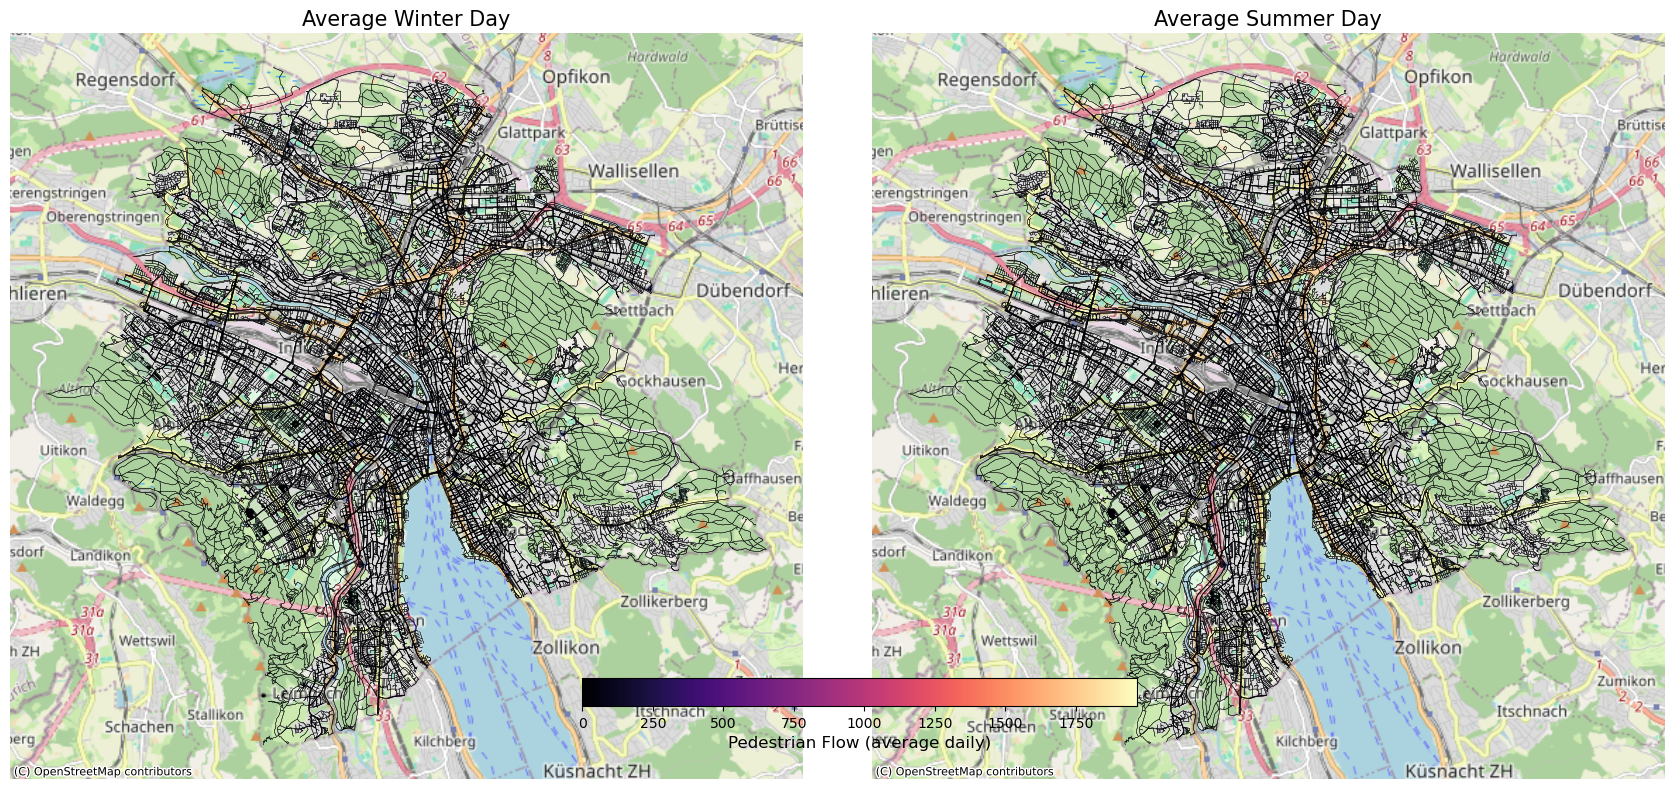

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

datasets = [
    ("Average Winter Day", winter_3857),
    ("Average Summer Day", summer_3857),
]

for ax, (title, gdf_season) in zip(axes, datasets):

    lw = BASE_LW + MAX_EXTRA_LW * (gdf_season["ped_flow"] / max_flow)
    colors = cmap(norm(gdf_season["ped_flow"].values))

    gdf_season.plot(
        ax=ax,
        color=colors,
        linewidth=lw,
        zorder=2,
    )

    ctx.add_basemap(
        ax,
        crs=gdf_season.crs,
        source=ctx.providers.OpenStreetMap.Mapnik,
        zorder=1,
    )

    ax.set_title(title, fontsize=15)
    ax.set_axis_off()
    ax.set_aspect("equal")

# Shared seasonal colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.045,
    pad=0.08,
)
cbar.set_label("Pedestrian Flow (average daily)", fontsize=12)

plt.tight_layout()
plt.show()
